## 0. Imports

In [310]:
# ============================================================
# 0. Imports
# ============================================================
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from scipy.stats import spearmanr, pearsonr
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW

## 1. Configuration

In [311]:
# ============================================================
# 1. Configuration
# ============================================================
NODES_CSV = "output/processed_fishtree_nodes.csv"
EDGE_INDEX_NPY = "output/processed_fishtree_edge_index.npy"
EDGE_WEIGHT_NPY = "output/processed_fishtree_edge_weight.npy"

DIST_MATRIX_PATH = "tree_distance_matrix_float32.npy"

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Model / optimization
EMB_DIM = 256 * 2
LR = 1e-5
WEIGHT_DECAY = 0.0
NUM_STEPS = 500_000
BATCH_SIZE = 512 * 4

# Loss
LAMBDA_PAIR = 1.0

# Distance binning
NUM_DISTANCE_BINS = 100
CLIP_DIST_PERCENTILE = 95.0

# Dense matrix construction
DIJKSTRA_BLOCK_SIZE = 256

# Unified sampler distributions
POS_LOCAL_ALPHA = 0.75
POS_UNIFORM_MIX = 0.50

NEG_OFFSET_ALPHA = 1.5
NEG_OFFSET_UNIFORM_MIX = 0.10

INCLUDE_OVERFLOW_AS_NEGATIVE = True

USE_WEIGHTED_TRIPLET_LOSS = False
WEIGHTED_TRIPLET_MODE = "soft"

USE_WEIGHTED_DISTANCE_LOSS = False
WEIGHTED_DISTANCE_MODE = "sqrt"

# Evaluation
EVAL_NUM_PAIR_SAMPLES = 3000
EVAL_NUM_ANCHORS = 200
EVAL_CANDIDATE_SIZE = 2000

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Using device:", DEVICE)

Using device: cuda


## 2. Load tree files

In [312]:
# ============================================================
# 2. Load tree files
# ============================================================
nodes_df = pd.read_csv(NODES_CSV)
edge_index = np.load(EDGE_INDEX_NPY)
edge_weight = np.load(EDGE_WEIGHT_NPY)

num_nodes = len(nodes_df)

print("num_nodes:", num_nodes)
print("edge_index shape:", edge_index.shape)
print("edge_weight shape:", edge_weight.shape)

is_leaf = nodes_df["is_leaf"].astype(bool).to_numpy()
leaf_ids = np.where(is_leaf)[0]
internal_ids = np.where(~is_leaf)[0]

print("num leaves:", len(leaf_ids))
print("num internal:", len(internal_ids))

num_nodes: 22919
edge_index shape: (2, 45836)
edge_weight shape: (45836,)
num leaves: 11460
num internal: 11459


## 3. Build sparse graph

In [313]:
# ============================================================
# 3. Build sparse graph
# ============================================================
def build_sparse_graph(edge_index, edge_weight, num_nodes):
    src = edge_index[0].astype(np.int64)
    dst = edge_index[1].astype(np.int64)
    data = edge_weight.astype(np.float64)
    return csr_matrix((data, (src, dst)), shape=(num_nodes, num_nodes))


graph = build_sparse_graph(edge_index, edge_weight, num_nodes)
print(graph)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 45836 stored elements and shape (22919, 22919)>
  Coords	Values
  (0, 1)	0.1449403315782547
  (0, 22896)	1.0290260314941406
  (1, 0)	0.1449403315782547
  (1, 2)	0.1516873687505722
  (1, 22845)	0.42339950799942017
  (2, 1)	0.1516873687505722
  (2, 3)	0.38424384593963623
  (2, 22830)	0.255990594625473
  (3, 2)	0.38424384593963623
  (3, 4)	0.08714011311531067
  (3, 22401)	0.1532358080148697
  (4, 3)	0.08714011311531067
  (4, 5)	0.21228080987930298
  (4, 22204)	0.12637940049171448
  (5, 4)	0.21228080987930298
  (5, 6)	0.10065711289644241
  (5, 15175)	0.09478769451379776
  (6, 5)	0.10065711289644241
  (6, 7)	0.12997013330459595
  (6, 15174)	0.850622832775116
  (7, 6)	0.12997013330459595
  (7, 8)	0.06234422326087952
  (7, 14957)	0.07460571080446243
  (8, 7)	0.06234422326087952
  (8, 9)	0.06394698470830917
  :	:
  (22902, 22906)	0.08762970566749573
  (22903, 22902)	0.016438767313957214
  (22903, 22904)	0.06075504422187805
  (22903,

## 4. Build or load dense distance matrix

In [314]:
# ============================================================
# 4. Build or load dense distance matrix
# ============================================================
def build_distance_matrix_blockwise(graph, num_nodes, out_path, block_size=256):
    out_path = Path(out_path)

    dist_mem = np.lib.format.open_memmap(
        out_path,
        mode="w+",
        dtype=np.float32,
        shape=(num_nodes, num_nodes),
    )

    row_starts = list(range(0, num_nodes, block_size))

    for start in tqdm(row_starts, desc="Computing distance matrix blocks"):
        end = min(start + block_size, num_nodes)
        indices = np.arange(start, end, dtype=np.int64)

        block = dijkstra(
            csgraph=graph,
            directed=False,
            indices=indices,
            return_predecessors=False,
        )

        dist_mem[start:end, :] = block.astype(np.float32)

    dist_mem.flush()
    del dist_mem


dist_matrix_path = Path(DIST_MATRIX_PATH)

if not dist_matrix_path.exists():
    build_distance_matrix_blockwise(
        graph=graph,
        num_nodes=num_nodes,
        out_path=dist_matrix_path,
        block_size=DIJKSTRA_BLOCK_SIZE,
    )

D = np.load(dist_matrix_path)
print("D shape:", D.shape, "dtype:", D.dtype)
print("Distance matrix memory GB:", D.nbytes / (1024 ** 3))

D shape: (22919, 22919) dtype: float32
Distance matrix memory GB: 1.9568225778639317


## 5. Estimate tau and clipping distance

In [315]:
# ============================================================
# 5. Estimate tau and clipping distance
# ============================================================
def sample_distance_distribution_from_dense(D, num_samples=100_000):
    n = D.shape[0]
    dists = []

    while len(dists) < num_samples:
        u = random.randrange(n)
        v = random.randrange(n)
        if u != v:
            dists.append(float(D[u, v]))

    return np.array(dists, dtype=np.float32)


dist_samples = sample_distance_distribution_from_dense(D)

tau = float(np.median(dist_samples))
clip_distance = float(np.percentile(dist_samples, CLIP_DIST_PERCENTILE))

print("Estimated tau:", tau)
print("clip_distance:", clip_distance)

for q in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"p{q:2d} = {np.percentile(dist_samples, q):.4f}")

Estimated tau: 2.238694429397583
clip_distance: 3.5185067653656006
p 1 = 0.3572
p 5 = 0.7280
p10 = 0.9282
p25 = 1.3611
p50 = 2.2387
p75 = 3.0069
p90 = 3.3084
p95 = 3.5185
p99 = 4.0006


## 6. Build compact equal-width band index

In [316]:
# ============================================================
# 6. Build compact equal-width band index
# ============================================================
def build_compact_band_index_from_dense(D, clip_distance, num_regular_bins):
    """
    Compact in-memory band index.

    sorted_ids[u] contains all other nodes sorted by D[u, node].
    bin_offsets[u, b]:bin_offsets[u, b+1] gives the slice for bin b.
    Final bin is overflow.
    """
    n = D.shape[0]
    num_total_bins = num_regular_bins + 1

    sorted_ids = np.empty((n, n - 1), dtype=np.int32)
    bin_offsets = np.empty((n, num_total_bins + 1), dtype=np.int32)

    bin_edges = np.linspace(0.0, clip_distance, num_regular_bins + 1, dtype=np.float32)

    for u in tqdm(range(n), desc="Building compact band index"):
        row = D[u]

        order = np.argsort(row, kind="stable")
        order = order[order != u]

        sorted_ids[u, :] = order.astype(np.int32, copy=False)

        sorted_dists = row[order]
        ends = np.searchsorted(sorted_dists, bin_edges[1:], side="right").astype(np.int32)

        bin_offsets[u, 0] = 0
        bin_offsets[u, 1:num_regular_bins + 1] = ends
        bin_offsets[u, num_total_bins] = n - 1

    return {
        "sorted_ids": sorted_ids,
        "bin_offsets": bin_offsets,
        "bin_edges": bin_edges,
        "clip_distance": float(clip_distance),
        "num_regular_bins": int(num_regular_bins),
        "num_total_bins": int(num_total_bins),
    }


band_index = build_compact_band_index_from_dense(
    D=D,
    clip_distance=clip_distance,
    num_regular_bins=NUM_DISTANCE_BINS,
)

sorted_ids = band_index["sorted_ids"]
bin_offsets = band_index["bin_offsets"]

print("sorted_ids:", sorted_ids.shape, sorted_ids.dtype)
print("bin_offsets:", bin_offsets.shape, bin_offsets.dtype)
print("Band index memory GB:", (sorted_ids.nbytes + bin_offsets.nbytes) / (1024 ** 3))

Building compact band index: 100%|██████████| 22919/22919 [00:18<00:00, 1237.81it/s]

sorted_ids: (22919, 22918) int32
bin_offsets: (22919, 102) int32
Band index memory GB: 1.965445950627327


## 7. Bias distributions for unified sampler

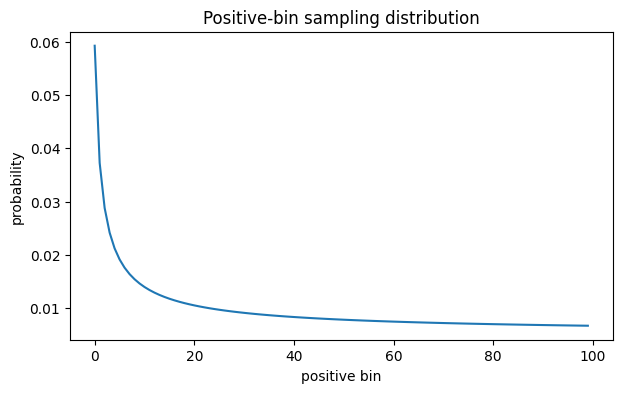

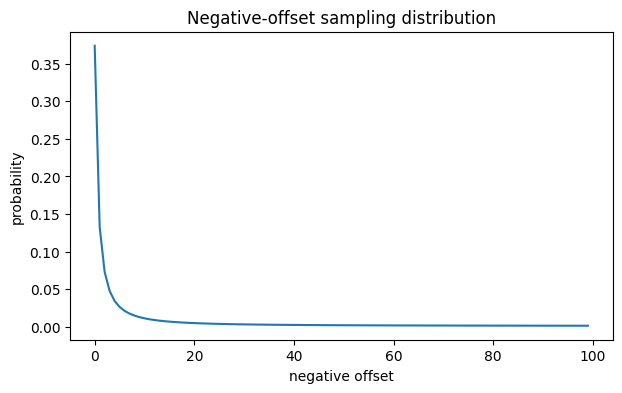

In [317]:
# ============================================================
# 7. Bias distributions for unified sampler
# ============================================================
def make_power_law_probs(num_items, alpha=1.0):
    x = np.arange(num_items, dtype=np.float64)
    probs = 1.0 / ((1.0 + x) ** alpha)
    probs /= probs.sum()
    return probs


def make_mixture_probs(num_items, local_alpha=1.5, uniform_mix=0.1):
    local = make_power_law_probs(num_items, alpha=local_alpha)
    uniform = np.ones(num_items, dtype=np.float64) / num_items
    probs = (1.0 - uniform_mix) * local + uniform_mix * uniform
    probs /= probs.sum()
    return probs


pos_bin_probs = make_mixture_probs(
    num_items=NUM_DISTANCE_BINS,
    local_alpha=POS_LOCAL_ALPHA,
    uniform_mix=POS_UNIFORM_MIX,
)

neg_offset_probs = make_mixture_probs(
    num_items=NUM_DISTANCE_BINS,
    local_alpha=NEG_OFFSET_ALPHA,
    uniform_mix=NEG_OFFSET_UNIFORM_MIX,
)

plt.figure(figsize=(7, 4))
plt.plot(pos_bin_probs)
plt.xlabel("positive bin")
plt.ylabel("probability")
plt.title("Positive-bin sampling distribution")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(neg_offset_probs)
plt.xlabel("negative offset")
plt.ylabel("probability")
plt.title("Negative-offset sampling distribution")
plt.show()

## 8. Unified distance-bin sampler

In [318]:
# ============================================================
# 8. Unified distance-bin sampler
# ============================================================
class UnifiedDistanceBinSampler:
    def __init__(
        self,
        D,
        sorted_ids,
        bin_offsets,
        num_regular_bins,
        include_overflow_as_negative=True,
        pos_bin_probs=None,
        neg_offset_probs=None,
        max_anchor_tries=100,
        max_bin_tries=100,
    ):
        self.D = D
        self.sorted_ids = sorted_ids
        self.bin_offsets = bin_offsets

        self.num_nodes = D.shape[0]
        self.num_regular_bins = num_regular_bins
        self.overflow_bin = num_regular_bins
        self.num_total_bins = num_regular_bins + 1

        self.include_overflow_as_negative = include_overflow_as_negative
        self.max_anchor_tries = max_anchor_tries
        self.max_bin_tries = max_bin_tries

        if pos_bin_probs is None:
            pos_bin_probs = make_mixture_probs(num_regular_bins, local_alpha=1.5, uniform_mix=0.05)

        if neg_offset_probs is None:
            neg_offset_probs = make_mixture_probs(num_regular_bins, local_alpha=1.25, uniform_mix=0.10)

        self.pos_bin_probs = np.asarray(pos_bin_probs, dtype=np.float64)
        self.pos_bin_probs /= self.pos_bin_probs.sum()

        self.neg_offset_probs = np.asarray(neg_offset_probs, dtype=np.float64)
        self.neg_offset_probs /= self.neg_offset_probs.sum()

    def _choose_anchor(self):
        return random.randrange(self.num_nodes)

    def _bin_slice(self, anchor, b):
        start = int(self.bin_offsets[anchor, b])
        end = int(self.bin_offsets[anchor, b + 1])
        return start, end

    def _bin_size(self, anchor, b):
        start, end = self._bin_slice(anchor, b)
        return end - start

    def _sample_pos_bin(self, anchor):
        for _ in range(self.max_bin_tries):
            b = int(np.random.choice(self.num_regular_bins, p=self.pos_bin_probs))
            if self._bin_size(anchor, b) > 0:
                return b
        return None

    def _sample_neg_bin(self, anchor, b_pos):
        max_regular_offset = self.num_regular_bins - 1 - b_pos

        for _ in range(self.max_bin_tries):
            offset = int(np.random.choice(len(self.neg_offset_probs), p=self.neg_offset_probs))

            if offset <= max_regular_offset:
                b_neg = b_pos + offset
            else:
                if self.include_overflow_as_negative:
                    b_neg = self.overflow_bin
                else:
                    b_neg = self.num_regular_bins - 1

            if self._bin_size(anchor, b_neg) > 0:
                return b_neg

        return None

    def _sample_from_bin_uniform(self, anchor, b):
        start, end = self._bin_slice(anchor, b)
        if end <= start:
            return None

        pos = random.randrange(start, end)
        node = int(self.sorted_ids[anchor, pos])
        d = float(self.D[anchor, node])
        return node, d, pos

    def _sample_same_bin_ordered_pair(self, anchor, b):
        start, end = self._bin_slice(anchor, b)
        size = end - start

        if size < 2:
            return None

        i = random.randrange(start, end - 1)
        j = random.randrange(i + 1, end)

        v = int(self.sorted_ids[anchor, i])
        w = int(self.sorted_ids[anchor, j])

        d_pos = float(self.D[anchor, v])
        d_neg = float(self.D[anchor, w])

        if d_pos < d_neg:
            return v, w, d_pos, d_neg
        if d_pos > d_neg:
            return w, v, d_neg, d_pos

        return None

    def sample_triplet(self):
        for _ in range(self.max_anchor_tries):
            anchor = self._choose_anchor()

            b_pos = self._sample_pos_bin(anchor)
            if b_pos is None:
                continue

            b_neg = self._sample_neg_bin(anchor, b_pos)
            if b_neg is None:
                continue

            if b_neg == b_pos:
                pair = self._sample_same_bin_ordered_pair(anchor, b_pos)
                if pair is None:
                    continue
                v, w, d_pos, d_neg = pair
            else:
                pos = self._sample_from_bin_uniform(anchor, b_pos)
                neg = self._sample_from_bin_uniform(anchor, b_neg)

                if pos is None or neg is None:
                    continue

                v, d_pos, _ = pos
                w, d_neg, _ = neg

                if d_pos > d_neg:
                    v, w = w, v
                    d_pos, d_neg = d_neg, d_pos

                if d_pos == d_neg:
                    continue

            return {
                "anchor": anchor,
                "pos": v,
                "neg": w,
                "d_pos": d_pos,
                "d_neg": d_neg,
                "b_pos": b_pos,
                "b_neg": b_neg,
                "bin_offset": b_neg - b_pos if b_neg < self.overflow_bin else self.overflow_bin - b_pos,
            }

        return None

    def sample_batch(self, batch_size):
        batch = []
        while len(batch) < batch_size:
            t = self.sample_triplet()
            if t is not None:
                batch.append(t)
        return batch


sampler = UnifiedDistanceBinSampler(
    D=D,
    sorted_ids=sorted_ids,
    bin_offsets=bin_offsets,
    num_regular_bins=NUM_DISTANCE_BINS,
    include_overflow_as_negative=INCLUDE_OVERFLOW_AS_NEGATIVE,
    pos_bin_probs=pos_bin_probs,
    neg_offset_probs=neg_offset_probs,
)

## 9. Inspect realized sampler behavior

Inspecting sampler:  64%|██████▎   | 6365/10000 [00:00<00:00, 63642.93it/s]

Inspecting sampler: 100%|██████████| 10000/10000 [00:00<00:00, 64273.03it/s]


,b_pos,b_neg,bin_offset,d_pos,d_neg,d_gap,same_bin,overflow_neg
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000
mean,40.33900,49.409700,9.070700,1.436726,1.778311,3.415848e-01,0.373500,0.084200
std,29.91208,31.983661,17.238417,1.052217,1.157178,6.319909e-01,0.483757,0.277701
min,0.00000,0.000000,0.000000,0.000001,0.002688,7.152557e-07,0.000000,0.000000
25%,13.00000,20.000000,0.000000,0.478163,0.738671,1.108040e-02,0.000000,0.000000
50%,36.00000,47.000000,1.000000,1.287362,1.684873,5.387962e-02,0.000000,0.000000
75%,66.00000,78.000000,8.000000,2.323953,2.769093,3.265243e-01,1.000000,0.000000
max,99.00000,100.000000,98.000000,3.518496,4.559425,3.810072e+00,1.000000,1.000000


same-bin fraction: 0.3735
overflow-negative fraction: 0.0842


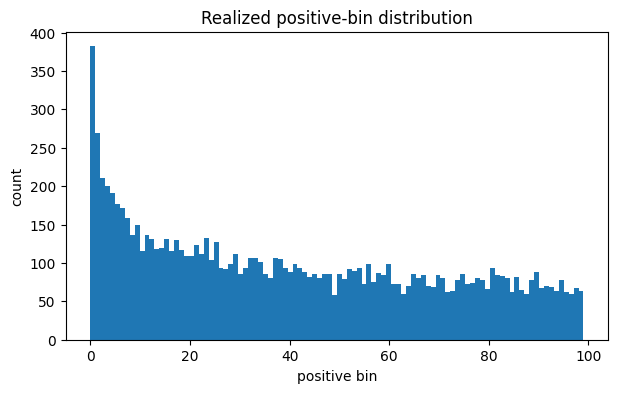

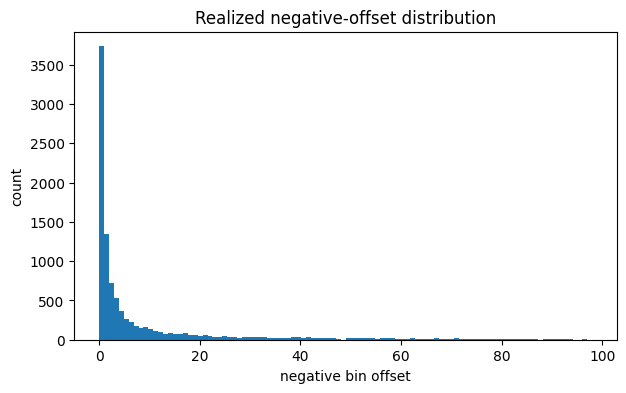

In [319]:
# ============================================================
# 9. Inspect realized sampler behavior
# ============================================================
def inspect_unified_sampler(sampler, num_samples=10000):
    records = []

    for _ in tqdm(range(num_samples), desc="Inspecting sampler"):
        t = sampler.sample_triplet()
        if t is None:
            continue

        records.append({
            "b_pos": t["b_pos"],
            "b_neg": t["b_neg"],
            "bin_offset": t["bin_offset"],
            "d_pos": t["d_pos"],
            "d_neg": t["d_neg"],
            "d_gap": t["d_neg"] - t["d_pos"],
            "same_bin": int(t["b_pos"] == t["b_neg"]),
            "overflow_neg": int(t["b_neg"] == sampler.overflow_bin),
        })

    return pd.DataFrame(records)


sampler_inspect_df = inspect_unified_sampler(sampler, num_samples=10000)

display(sampler_inspect_df.describe())

print("same-bin fraction:", sampler_inspect_df["same_bin"].mean())
print("overflow-negative fraction:", sampler_inspect_df["overflow_neg"].mean())

plt.figure(figsize=(7, 4))
plt.hist(sampler_inspect_df["b_pos"], bins=100)
plt.xlabel("positive bin")
plt.ylabel("count")
plt.title("Realized positive-bin distribution")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(sampler_inspect_df["bin_offset"], bins=100)
plt.xlabel("negative bin offset")
plt.ylabel("count")
plt.title("Realized negative-offset distribution")
plt.show()

## 10. Model

In [320]:
# ============================================================
# 10. Model
# ============================================================
class NodeEmbeddingModel(nn.Module):
    def __init__(self, num_nodes, emb_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, emb_dim)
        nn.init.xavier_uniform_(self.embedding.weight)

    def forward(self, node_ids):
        z = self.embedding(node_ids)
        return F.normalize(z, p=2, dim=-1)

    def get_all_embeddings(self):
        return F.normalize(self.embedding.weight, p=2, dim=-1)

## 11. Loss

In [321]:
# ============================================================
# 11. Loss (modular weighting)
# ============================================================
def cosine_sim(a, b):
    return (a * b).sum(dim=-1)


def pair_target_from_distance(d, tau):
    #return torch.exp(-d / tau)
    return 1.0 / (1.0 + d / tau)


# -------------------------
# Distance weighting options
# -------------------------
def compute_distance_weight(d, mode="none"):
    """
    mode:
        "none"   -> no weighting
        "inverse"-> 1 / (1 + d)
        "sqrt"   -> 1 / sqrt(1 + d)
    """
    if mode == "none":
        return torch.ones_like(d)
    elif mode == "inverse":
        return 1.0 / (1.0 + d)
    elif mode == "sqrt":
        return 1.0 / torch.sqrt(1.0 + d)
    else:
        raise ValueError(f"Unknown distance weight mode: {mode}")


# -------------------------
# Triplet weighting options
# -------------------------
def compute_triplet_weight(offsets, mode="none"):
    """
    offsets: tensor of bin offsets

    mode:
        "none"        -> uniform
        "offset_inv"  -> 0.5 + 1.5 / (1 + offset)
        "soft"        -> 1 / sqrt(1 + offset)
    """
    if mode == "none":
        return torch.ones_like(offsets)
    elif mode == "offset_inv":
        return 0.5 + 1.5 / (1.0 + offsets)
    elif mode == "soft":
        return 1.0 / torch.sqrt(1.0 + offsets)
    else:
        raise ValueError(f"Unknown triplet weight mode: {mode}")


# -------------------------
# Main loss
# -------------------------
def compute_loss_unified(
    model,
    batch_triplets,
    tau,
    lambda_pair=0.2,
    device="cpu",
    use_triplet_weighting=False,
    triplet_weight_mode="offset_inv",
    use_distance_weighting=False,
    distance_weight_mode="inverse",
):
    # -------------------------
    # Build tensors
    # -------------------------
    u = torch.tensor([t["anchor"] for t in batch_triplets], dtype=torch.long, device=device)
    v = torch.tensor([t["pos"] for t in batch_triplets], dtype=torch.long, device=device)
    w = torch.tensor([t["neg"] for t in batch_triplets], dtype=torch.long, device=device)

    d_uv = torch.tensor([t["d_pos"] for t in batch_triplets], dtype=torch.float32, device=device)
    d_uw = torch.tensor([t["d_neg"] for t in batch_triplets], dtype=torch.float32, device=device)

    # -------------------------
    # Forward pass
    # -------------------------
    z_u = model(u)
    z_v = model(v)
    z_w = model(w)

    s_uv = cosine_sim(z_u, z_v)
    s_uw = cosine_sim(z_u, z_w)

    # ============================================================
    # Triplet loss
    # ============================================================
    triplet_terms = F.relu(-s_uv + s_uw)  # margin = 0

    if use_triplet_weighting:
        offsets = torch.tensor(
            [t["bin_offset"] for t in batch_triplets],
            dtype=torch.float32,
            device=device,
        )
        triplet_weights = compute_triplet_weight(offsets, mode=triplet_weight_mode)
        triplet_loss = (triplet_weights * triplet_terms).mean()
    else:
        triplet_loss = triplet_terms.mean()

    # ============================================================
    # Pair loss
    # ============================================================
    target_uv = pair_target_from_distance(d_uv, tau)
    target_uw = pair_target_from_distance(d_uw, tau)

    if use_distance_weighting:
        weight_uv = compute_distance_weight(d_uv, mode=distance_weight_mode)
        weight_uw = compute_distance_weight(d_uw, mode=distance_weight_mode)
    else:
        weight_uv = torch.ones_like(d_uv)
        weight_uw = torch.ones_like(d_uw)

    pair_loss = (
        (weight_uv * (s_uv - target_uv) ** 2).mean()
        + (weight_uw * (s_uw - target_uw) ** 2).mean()
    )

    # ============================================================
    # Total loss
    # ============================================================
    total_loss = triplet_loss + lambda_pair * pair_loss

    # ============================================================
    # Stats
    # ============================================================
    stats = {
        "loss": float(total_loss.item()),
        "triplet_loss": float(triplet_loss.item()),
        "pair_loss": float(pair_loss.item()),
        "mean_sim_pos": float(s_uv.mean().item()),
        "mean_sim_neg": float(s_uw.mean().item()),
        "mean_d_pos": float(d_uv.mean().item()),
        "mean_d_neg": float(d_uw.mean().item()),
        "mean_d_gap": float((d_uw - d_uv).mean().item()),
    }

    if use_triplet_weighting:
        stats["mean_triplet_weight"] = float(triplet_weights.mean().item())

    if use_distance_weighting:
        stats["mean_pair_weight"] = float(weight_uv.mean().item())

    return total_loss, stats

## 12. Training

In [322]:
# ============================================================
# 12. Training
# ============================================================
model = NodeEmbeddingModel(num_nodes=num_nodes, emb_dim=EMB_DIM).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history = []

for step in range(NUM_STEPS):
    batch = sampler.sample_batch(BATCH_SIZE)

    optimizer.zero_grad()
    loss, stats = compute_loss_unified(
        model=model,
        batch_triplets=batch,
        tau=tau,
        lambda_pair=LAMBDA_PAIR,
        device=DEVICE,
        use_triplet_weighting=USE_WEIGHTED_TRIPLET_LOSS,
        triplet_weight_mode=WEIGHTED_TRIPLET_MODE,
        use_distance_weighting=USE_WEIGHTED_DISTANCE_LOSS,
        distance_weight_mode=WEIGHTED_DISTANCE_MODE
    )
    loss.backward()
    optimizer.step()

    history.append(stats)

    if step % 200 == 0:
        print(
            f"step={step:6d}  "
            f"loss={stats['loss']:.4f}  "
            f"triplet={stats['triplet_loss']:.4f}  "
            f"pair={stats['pair_loss']:.4f}  "
            f"d_pos={stats['mean_d_pos']:.4f}  "
            f"d_neg={stats['mean_d_neg']:.4f}"
        )

step=     0  loss=0.8990  triplet=0.0238  pair=0.8752  d_pos=1.4704  d_neg=1.8006
step=   200  loss=0.9203  triplet=0.0259  pair=0.8944  d_pos=1.4051  d_neg=1.7690
step=   400  loss=0.9160  triplet=0.0247  pair=0.8913  d_pos=1.4285  d_neg=1.7528
step=   600  loss=0.9303  triplet=0.0244  pair=0.9059  d_pos=1.3962  d_neg=1.7261
step=   800  loss=0.9186  triplet=0.0239  pair=0.8947  d_pos=1.4001  d_neg=1.7465
step=  1000  loss=0.9078  triplet=0.0246  pair=0.8832  d_pos=1.4359  d_neg=1.7864
step=  1200  loss=0.8890  triplet=0.0240  pair=0.8650  d_pos=1.4502  d_neg=1.8019
step=  1400  loss=0.8873  triplet=0.0241  pair=0.8633  d_pos=1.4573  d_neg=1.7920
step=  1600  loss=0.9100  triplet=0.0237  pair=0.8862  d_pos=1.4102  d_neg=1.7397
step=  1800  loss=0.9011  triplet=0.0250  pair=0.8761  d_pos=1.4340  d_neg=1.7784
step=  2000  loss=0.9014  triplet=0.0243  pair=0.8771  d_pos=1.4042  d_neg=1.7492
step=  2200  loss=0.9115  triplet=0.0233  pair=0.8882  d_pos=1.3833  d_neg=1.7167
step=  2400  los

## 13. Plot training curves

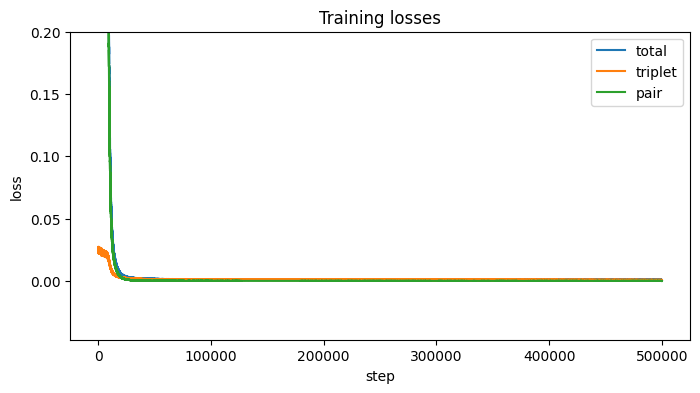

In [323]:
# ============================================================
# 13. Plot training curves
# ============================================================
losses = [x["loss"] for x in history]
triplet_losses = [x["triplet_loss"] for x in history]
pair_losses = [x["pair_loss"] for x in history]

plt.figure(figsize=(8, 4))
plt.plot(losses, label="total")
plt.plot(triplet_losses, label="triplet")
plt.plot(pair_losses, label="pair")
plt.ylim(top=0.2)
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.title("Training losses")
plt.show()

## 14. Evaluation helpers

In [324]:
# ============================================================
# 14. Evaluation helpers
# ============================================================
@torch.no_grad()
def cosine_similarity_to_candidates(model, anchor, candidates, device="cpu"):
    model.eval()
    nodes = torch.tensor([anchor] + list(candidates), dtype=torch.long, device=device)
    z = model(nodes)
    sims = torch.matmul(z[1:], z[0])
    return sims.cpu().numpy()


@torch.no_grad()
def evaluate_cutoff_correlation_dense(
    model,
    D,
    node_ids_a,
    node_ids_b,
    max_tree_dist,
    num_samples=3000,
    device="cpu",
    max_tries=200000,
):
    model.eval()
    dists = []
    neg_sims = []
    tries = 0

    node_ids_a = list(node_ids_a)
    node_ids_b = list(node_ids_b)

    while len(dists) < num_samples and tries < max_tries:
        tries += 1

        u = int(random.choice(node_ids_a))
        v = int(random.choice(node_ids_b))
        if u == v:
            continue

        d = float(D[u, v])
        if d > max_tree_dist:
            continue

        z = model(torch.tensor([u, v], dtype=torch.long, device=device))
        sim = float((z[0] * z[1]).sum().item())

        dists.append(d)
        neg_sims.append(-sim)

    if len(dists) < 10:
        return {"num_pairs": len(dists), "spearman": np.nan, "pearson": np.nan}

    return {
        "num_pairs": len(dists),
        "spearman": float(spearmanr(dists, neg_sims).correlation),
        "pearson": float(pearsonr(dists, neg_sims)[0]),
    }


@torch.no_grad()
def evaluate_binwise_correlation_dense(
    model,
    D,
    node_ids_a,
    node_ids_b,
    bin_edges,
    num_samples_per_bin=1000,
    device="cpu",
    max_tries_per_bin=200000,
):
    model.eval()

    node_ids_a = list(node_ids_a)
    node_ids_b = list(node_ids_b)
    results = []

    for b in tqdm(range(len(bin_edges) - 1), desc="Bin-wise evaluation"):
        low = float(bin_edges[b])
        high = float(bin_edges[b + 1])

        dists = []
        neg_sims = []
        tries = 0

        while len(dists) < num_samples_per_bin and tries < max_tries_per_bin:
            tries += 1

            u = int(random.choice(node_ids_a))
            v = int(random.choice(node_ids_b))
            if u == v:
                continue

            d = float(D[u, v])
            if not (low < d <= high):
                continue

            z = model(torch.tensor([u, v], dtype=torch.long, device=device))
            sim = float((z[0] * z[1]).sum().item())

            dists.append(d)
            neg_sims.append(-sim)

        if len(dists) >= 10:
            spearman = float(spearmanr(dists, neg_sims).correlation)
            pearson = float(pearsonr(dists, neg_sims)[0])
        else:
            spearman = np.nan
            pearson = np.nan

        results.append({
            "bin_index": b,
            "low": low,
            "high": high,
            "num_pairs": len(dists),
            "spearman": spearman,
            "pearson": pearson,
        })

    return pd.DataFrame(results)


@torch.no_grad()
def evaluate_triplet_accuracy_unified(model, sampler, num_triplets=5000, device="cpu"):
    model.eval()
    records = []

    for _ in range(num_triplets):
        t = sampler.sample_triplet()
        if t is None:
            continue

        u, v, w = t["anchor"], t["pos"], t["neg"]

        z = model(torch.tensor([u, v, w], dtype=torch.long, device=device))
        s_uv = float((z[0] * z[1]).sum().item())
        s_uw = float((z[0] * z[2]).sum().item())

        records.append({
            "correct": float(s_uv > s_uw),
            "observed_margin": s_uv - s_uw,
            "b_pos": t["b_pos"],
            "b_neg": t["b_neg"],
            "bin_offset": t["bin_offset"],
            "d_pos": t["d_pos"],
            "d_neg": t["d_neg"],
            "d_gap": t["d_neg"] - t["d_pos"],
            "same_bin": int(t["b_pos"] == t["b_neg"]),
        })

    df = pd.DataFrame(records)

    return {
        "overall_accuracy": float(df["correct"].mean()),
        "num_triplets": int(len(df)),
        "same_bin_accuracy": float(df.loc[df["same_bin"] == 1, "correct"].mean()),
        "different_bin_accuracy": float(df.loc[df["same_bin"] == 0, "correct"].mean()),
        "mean_observed_margin": float(df["observed_margin"].mean()),
        "mean_d_gap": float(df["d_gap"].mean()),
    }, df

## 15. Neighbor retrieval metrics

In [325]:
# ============================================================
# 15. Neighbor retrieval metrics
# ============================================================
def recall_at_k_single_dense(model, D, anchor, candidates, k, device="cpu"):
    dists = D[anchor, candidates]
    true_order = np.argsort(dists)
    true_topk = set([candidates[i] for i in true_order[:k]])

    sims = cosine_similarity_to_candidates(model, anchor, candidates, device)
    pred_order = np.argsort(-sims)
    pred_topk = set([candidates[i] for i in pred_order[:k]])

    return len(true_topk & pred_topk) / k


@torch.no_grad()
def evaluate_recall_at_k_dense(
    model,
    D,
    node_ids,
    k=10,
    num_anchors=200,
    candidate_size=2000,
    device="cpu",
):
    recalls = []
    node_ids = list(node_ids)

    for _ in range(num_anchors):
        anchor = int(random.choice(node_ids))
        candidates = random.sample(node_ids, min(candidate_size, len(node_ids)))

        if anchor in candidates:
            candidates.remove(anchor)

        if len(candidates) < k:
            continue

        recalls.append(
            recall_at_k_single_dense(model, D, anchor, candidates, k, device=device)
        )

    return {
        "k": k,
        "num_anchors": len(recalls),
        "mean_recall": float(np.mean(recalls)),
        "std_recall": float(np.std(recalls)),
    }


@torch.no_grad()
def evaluate_embedding_neighbor_tree_distance_dense(
    model,
    D,
    node_ids,
    k=10,
    num_anchors=200,
    candidate_size=2000,
    device="cpu",
):
    mean_distances = []
    node_ids = list(node_ids)

    for _ in range(num_anchors):
        anchor = int(random.choice(node_ids))
        candidates = random.sample(node_ids, min(candidate_size, len(node_ids)))

        if anchor in candidates:
            candidates.remove(anchor)

        if len(candidates) < k:
            continue

        sims = cosine_similarity_to_candidates(model, anchor, candidates, device)
        pred_order = np.argsort(-sims)
        pred_topk = [candidates[i] for i in pred_order[:k]]

        mean_distances.append(float(np.mean(D[anchor, pred_topk])))

    return {
        "k": k,
        "num_anchors": len(mean_distances),
        "mean_tree_distance": float(np.mean(mean_distances)),
        "std_tree_distance": float(np.std(mean_distances)),
    }


@torch.no_grad()
def evaluate_anchor_local_ranking_spearman(
    model,
    D,
    node_ids,
    neighborhood_size=50,
    num_anchors=200,
    candidate_pool_size=2000,
    device="cpu",
):
    scores = []
    node_ids = list(node_ids)

    for _ in range(num_anchors):
        anchor = int(random.choice(node_ids))
        candidates = random.sample(node_ids, min(candidate_pool_size, len(node_ids)))

        if anchor in candidates:
            candidates.remove(anchor)

        if len(candidates) < neighborhood_size:
            continue

        dists = D[anchor, candidates]
        true_order = np.argsort(dists)
        neighborhood = [candidates[i] for i in true_order[:neighborhood_size]]

        d_local = D[anchor, neighborhood]
        true_rank = np.argsort(np.argsort(d_local))

        sims = cosine_similarity_to_candidates(model, anchor, neighborhood, device)
        pred_rank = np.argsort(np.argsort(-sims))

        rho = spearmanr(true_rank, pred_rank).correlation
        scores.append(float(rho))

    return {
        "num_anchors": len(scores),
        "mean_spearman": float(np.mean(scores)),
        "std_spearman": float(np.std(scores)),
    }

## 16. Focused evaluation suite

In [328]:
# ============================================================
# 16. Focused evaluation suite
# ============================================================
def run_focused_evaluation_suite(
    model,
    D,
    band_index,
    sampler,
    leaf_ids,
    device="cpu",
):
    cutoff_results = []
    for threshold in [band_index["bin_edges"][t] for t in [5, 10, 20, 40, 60, 80]]:
        res = evaluate_cutoff_correlation_dense(
            model=model,
            D=D,
            node_ids_a=leaf_ids,
            node_ids_b=leaf_ids,
            max_tree_dist=threshold,
            num_samples=EVAL_NUM_PAIR_SAMPLES,
            device=device,
        )
        res["max_tree_dist"] = threshold
        cutoff_results.append(res)

    cutoff_df = pd.DataFrame(cutoff_results)

    binwise_df = evaluate_binwise_correlation_dense(
        model=model,
        D=D,
        node_ids_a=leaf_ids,
        node_ids_b=leaf_ids,
        bin_edges=band_index["bin_edges"],
        num_samples_per_bin=1000,
        device=device,
    )

    triplet_summary, triplet_df = evaluate_triplet_accuracy_unified(
        model=model,
        sampler=sampler,
        num_triplets=5000,
        device=device,
    )

    recall_10 = evaluate_recall_at_k_dense(
        model=model,
        D=D,
        node_ids=leaf_ids,
        k=10,
        num_anchors=EVAL_NUM_ANCHORS,
        candidate_size=EVAL_CANDIDATE_SIZE,
        device=device,
    )

    neighbor_dist_10 = evaluate_embedding_neighbor_tree_distance_dense(
        model=model,
        D=D,
        node_ids=leaf_ids,
        k=10,
        num_anchors=EVAL_NUM_ANCHORS,
        candidate_size=EVAL_CANDIDATE_SIZE,
        device=device,
    )

    anchor_local_rank = evaluate_anchor_local_ranking_spearman(
        model=model,
        D=D,
        node_ids=leaf_ids,
        neighborhood_size=50,
        num_anchors=EVAL_NUM_ANCHORS,
        candidate_pool_size=EVAL_CANDIDATE_SIZE,
        device=device,
    )

    return {
        "cutoff_df": cutoff_df,
        "binwise_df": binwise_df,
        "triplet_summary": triplet_summary,
        "triplet_df": triplet_df,
        "recall_10": recall_10,
        "neighbor_dist_10": neighbor_dist_10,
        "anchor_local_rank": anchor_local_rank,
    }


eval_results = run_focused_evaluation_suite(
    model=model,
    D=D,
    band_index=band_index,
    sampler=sampler,
    leaf_ids=leaf_ids,
    device=DEVICE,
)

display(eval_results["cutoff_df"])
print(eval_results["triplet_summary"])
print(eval_results["recall_10"])
print(eval_results["neighbor_dist_10"])
print(eval_results["anchor_local_rank"])

Bin-wise evaluation: 100%|██████████| 100/100 [00:11<00:00,  8.78it/s]


,num_pairs,spearman,pearson,max_tree_dist
0,357,0.971752,0.956725,0.175925
1,1334,0.989565,0.989350,0.351851
2,3000,0.990052,0.993432,0.703701
3,3000,0.984129,0.985084,1.407403
4,3000,0.993680,0.981740,2.111104
5,3000,0.996215,0.977656,2.814806


{'overall_accuracy': 0.857, 'num_triplets': 5000, 'same_bin_accuracy': 0.7028788701792504, 'different_bin_accuracy': 0.9468186134852802, 'mean_observed_margin': 0.0541843572974205, 'mean_d_gap': 0.34387586782960416}
{'k': 10, 'num_anchors': 200, 'mean_recall': 0.9175, 'std_recall': 0.09871043511199817}
{'k': 10, 'num_anchors': 200, 'mean_tree_distance': 0.4184201117604971, 'std_tree_distance': 0.24204246366093798}
{'num_anchors': 200, 'mean_spearman': 0.9375591836734694, 'std_spearman': 0.06807479675466155}


## 17. Plot bin-wise correlation

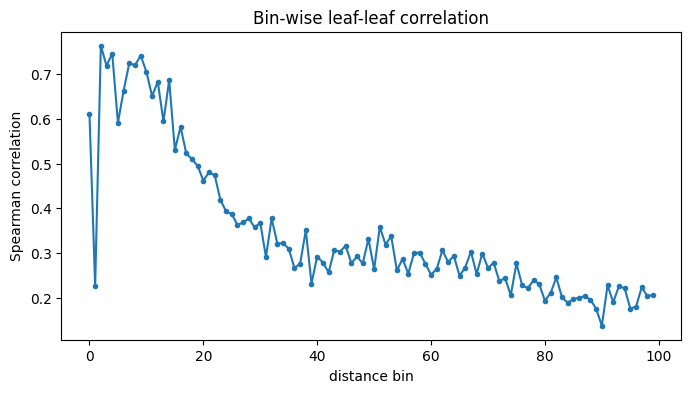

In [327]:
# ============================================================
# 17. Plot bin-wise correlation
# ============================================================
binwise_df = eval_results["binwise_df"]

plt.figure(figsize=(8, 4))
plt.plot(binwise_df["bin_index"], binwise_df["spearman"], marker="o", markersize=3)
plt.xlabel("distance bin")
plt.ylabel("Spearman correlation")
plt.title("Bin-wise leaf-leaf correlation")
plt.show()